In [16]:
!pip install pandas

In [17]:
!pip install seaborn

In [18]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path

Project_Folder = Path.cwd().parent

df = pd.read_csv(Project_Folder / 'data' / 'raw' / 'dataset.csv')


print(f"sheap :{df.shape}")
print("#" * 50)
print(f"Columns :{df.columns.tolist()}")
print("#" * 50)
print(df.info())
print("#" * 50)
print(df.describe())
print("#" * 50)
print(df.head(10))
print("#" * 50)
print(df.isnull().sum())
print("#" * 50)
print(df[df.isnull().any(axis=1)].shape[0], "rows have at least one missing value")
print("#" * 50)


sheap :(45593, 20)
##################################################
Columns :['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']
##################################################
<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitud

In [3]:
for col in ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']:
    print(col, ":", df[col].unique())
    print("-" * 40)

Delivery_person_Age : <StringArray>
[  '37',   '34',   '23',   '38',   '32',   '22',   '33',   '35',   '36',
   '21',   '24',   '29',   '25',   '31',   '27',   '26',   '20', 'NaN ',
   '28',   '39',   '30',   '15',   '50']
Length: 23, dtype: str
----------------------------------------
Delivery_person_Ratings : <StringArray>
[ '4.9',  '4.5',  '4.4',  '4.7',  '4.6',  '4.8',  '4.2',  '4.3',    '4',
  '4.1',    '5',  '3.5', 'NaN ',  '3.8',  '3.9',  '3.7',  '2.6',  '2.5',
  '3.6',  '3.1',  '2.7',    '1',  '3.2',  '3.3',    '6',  '3.4',  '2.8',
  '2.9',    '3']
Length: 29, dtype: str
----------------------------------------
multiple_deliveries : <StringArray>
['0', '1', '3', 'NaN ', '2']
Length: 5, dtype: str
----------------------------------------


In [4]:
column_fix = ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries']

for c in column_fix:
    df[c] = df[c].str.strip()
    df[c] = df[c].replace('NaN',np.nan)
    df[c] = pd.to_numeric(df[c],errors='coerce')
    
print(df[column_fix].dtypes)
print("-" * 40)
print(df[column_fix].isnull().sum())

Delivery_person_Age        float64
Delivery_person_Ratings    float64
multiple_deliveries        float64
dtype: object
----------------------------------------
Delivery_person_Age        1854
Delivery_person_Ratings    1908
multiple_deliveries         993
dtype: int64


In [5]:
for col in ['Delivery_person_Age', 'Delivery_person_Ratings']:
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = df[col].skew()
    print(f"{col} -> mean: {mean_val:.2f}, median: {median_val:.2f}, skew: {skew_val:.2f}")
    print("-" * 40)

Delivery_person_Age -> mean: 29.57, median: 30.00, skew: 0.02
----------------------------------------
Delivery_person_Ratings -> mean: 4.63, median: 4.70, skew: -2.49
----------------------------------------


Calculate skew.
Skew close to 0 → mean or median, either is fine.
Skew far from 0 (positive or negative) → use median (more robust to the skew/outliers pulling the mean away from the "typical" value).

In [6]:
mean_age = df['Delivery_person_Age'].mean()
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(mean_age)


In [7]:
median_rating = df['Delivery_person_Ratings'].median()
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(median_rating)


In [8]:
mode_deliveries = df['multiple_deliveries'].mode()[0]
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(mode_deliveries)


In [9]:
df[['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']].isnull().sum()

Delivery_person_Age        0
Delivery_person_Ratings    0
multiple_deliveries        0
dtype: int64

In [10]:
df['Delivery_person_Age'] = df['Delivery_person_Age'].astype(int)
df['multiple_deliveries'] = df['multiple_deliveries'].astype(int)
df[['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']].dtypes

Delivery_person_Age          int64
Delivery_person_Ratings    float64
multiple_deliveries          int64
dtype: object

In [11]:
print(df['Weatherconditions'].unique())
print("-" * 40)
print(df['Time_taken(min)'].unique()[:15])
print("-" * 40)
print(df['City'].unique())
print("-" * 40)
print(df['Type_of_vehicle'].unique())

<StringArray>
[     'conditions Sunny',     'conditions Stormy', 'conditions Sandstorms',
     'conditions Cloudy',        'conditions Fog',      'conditions Windy',
        'conditions NaN']
Length: 7, dtype: str
----------------------------------------
<StringArray>
['(min) 24', '(min) 33', '(min) 26', '(min) 21', '(min) 30', '(min) 40',
 '(min) 32', '(min) 34', '(min) 46', '(min) 23', '(min) 20', '(min) 41',
 '(min) 15', '(min) 36', '(min) 39']
Length: 15, dtype: str
----------------------------------------
<StringArray>
['Urban ', 'Metropolitian ', 'Semi-Urban ', 'NaN ']
Length: 4, dtype: str
----------------------------------------
<StringArray>
['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle ']
Length: 4, dtype: str


In [12]:
df['Weatherconditions'] = df['Weatherconditions'].str.replace("conditions","",regex=False).str.strip()
df['Weatherconditions'] = df['Weatherconditions'].replace('nan', np.nan)
mode_weather = df['Weatherconditions'].mode()[0]
df['Weatherconditions'] = df['Weatherconditions'].fillna(mode_weather)


In [13]:
print(df['Weatherconditions'].unique())
print("-" * 40)
print(df['Weatherconditions'].isnull().sum())


<StringArray>
['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', 'NaN']
Length: 7, dtype: str
----------------------------------------
0


In [14]:

df['Time_taken(min)'] = df['Time_taken(min)'].str.split(' ').str[1]
df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')
df['City'] = df['City'].str.strip()
df['City'] = df['City'].replace('NaN', np.nan)
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.strip()

In [15]:
print(df['Time_taken(min)'].head())
print(df['Time_taken(min)'].dtype)
print("-" * 40)
print(df['City'].unique())
print("-" * 40)
print(df['Type_of_vehicle'].unique())
print("-" * 40)
print(df[['Weatherconditions', 'City']].isnull().sum())

0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: int64
int64
----------------------------------------
<StringArray>
['Urban', 'Metropolitian', 'Semi-Urban', nan]
Length: 4, dtype: str
----------------------------------------
<StringArray>
['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
Length: 4, dtype: str
----------------------------------------
Weatherconditions       0
City                 1200
dtype: int64


In [16]:
mode_city = df['City'].mode()[0]
df['City'] = df['City'].fillna(mode_city)

In [17]:
print(df['City'].isnull().sum())

0


In [18]:
df[['Restaurant_latitude', 'Restaurant_longitude', 
          'Delivery_location_latitude', 'Delivery_location_longitude']].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702
std,8.185109,22.883647,7.335122,21.118812
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.546947,75.898497,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


In [19]:
print("Negative Restaurant_latitude:", (df['Restaurant_latitude'] < 0).sum())
print("Negative Delivery_location_latitude:", (df['Delivery_location_latitude'] < 0).sum())
print("Negative Restaurant_longitude:", (df['Restaurant_longitude'] < 0).sum())
print("Negative Delivery_location_longitude:", (df['Delivery_location_longitude'] < 0).sum())

Negative Restaurant_latitude: 431
Negative Delivery_location_latitude: 0
Negative Restaurant_longitude: 162
Negative Delivery_location_longitude: 0


In [20]:
df[df['Restaurant_latitude'] < 0][['Restaurant_latitude', 'Restaurant_longitude',
                                     'Delivery_location_latitude', 'Delivery_location_longitude']].head(10)

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
92,-27.163303,78.057044,27.233303,78.127044
283,-27.165108,78.015053,27.225108,78.075053
289,-18.551440,-73.804855,18.611440,73.864855
425,-30.366322,-78.070453,30.496322,78.200453
534,-12.325461,-76.632278,12.385461,76.692278
583,-12.316967,76.603067,12.326967,76.613067
762,-23.359194,-85.325447,23.449194,85.415447
1059,-26.477750,-80.351569,26.487750,80.361569
1091,-15.546594,73.760431,15.606594,73.820431
1157,-12.337978,76.616792,12.387978,76.666792


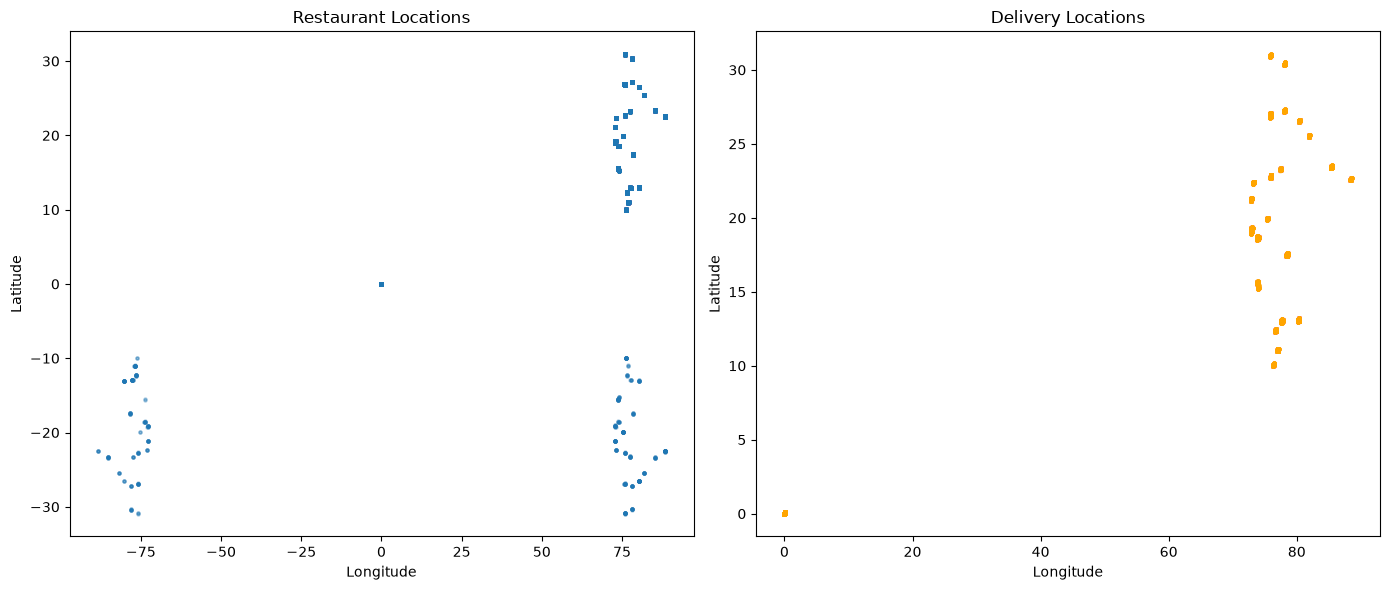

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df['Restaurant_longitude'], df['Restaurant_latitude'], alpha=0.3, s=5)
axes[0].set_title('Restaurant Locations')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

axes[1].scatter(df['Delivery_location_longitude'], df['Delivery_location_latitude'], alpha=0.3, s=5, color='orange')
axes[1].set_title('Delivery Locations')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

In [22]:
df['Restaurant_latitude'] = df['Restaurant_latitude'].abs()
df['Restaurant_longitude'] = df['Restaurant_longitude'].abs()
print("Negative Restaurant_latitude:", (df['Restaurant_latitude'] < 0).sum())
print("Negative Restaurant_longitude:", (df['Restaurant_longitude'] < 0).sum())

Negative Restaurant_latitude: 0
Negative Restaurant_longitude: 0


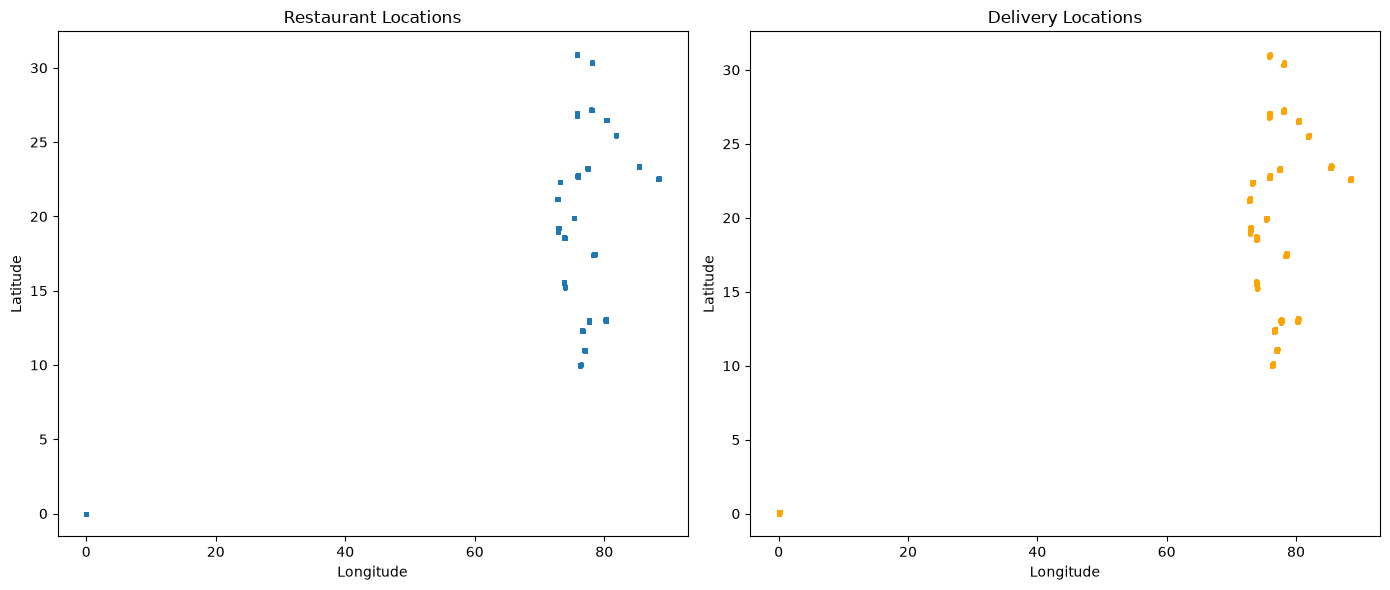

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df['Restaurant_longitude'], df['Restaurant_latitude'], alpha=0.3, s=5)
axes[0].set_title('Restaurant Locations')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

axes[1].scatter(df['Delivery_location_longitude'], df['Delivery_location_latitude'], alpha=0.3, s=5, color='orange')
axes[1].set_title('Delivery Locations')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

In [24]:
zero_mask = (
    (df['Restaurant_latitude'].abs() < 1) |
    (df['Restaurant_longitude'].abs() < 1) |
    (df['Delivery_location_latitude'].abs() < 1) |
    (df['Delivery_location_longitude'].abs() < 1)
)

print("Rows to drop:", zero_mask.sum())

df = df[~zero_mask]

print("New shape:", df.shape)

Rows to drop: 3640
New shape: (41953, 20)


### GPS Coordinate Cleaning

- `Restaurant_latitude`/`Restaurant_longitude` contained sign errors (both flipped
  together) for a subset of rows — confirmed by matching magnitude with valid
  coordinates and visual clustering. Fixed using `.abs()`.
- A small number of rows had near-zero (~0.01) coordinates on either the
  restaurant or delivery side — physically implausible (falls in the ocean,
  far from India) and unrecoverable. These rows were dropped.

In [25]:
print(len(df))

41953


In [26]:
df_check = pd.read_csv(Project_Folder / 'data' / 'raw' / 'dataset.csv')


zero_mask_check = (
    (df_check['Restaurant_latitude'].abs() < 1) |
    (df_check['Restaurant_longitude'].abs() < 1) |
    (df_check['Delivery_location_latitude'].abs() < 1) |
    (df_check['Delivery_location_longitude'].abs() < 1)
)

df_check[zero_mask_check][['Restaurant_latitude','Restaurant_longitude',
                                    'Delivery_location_latitude','Delivery_location_longitude']].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,3640.0,3640.0,3640.000000,3640.000000
mean,0.0,0.0,0.063016,0.063016
std,0.0,0.0,0.036047,0.036047
min,0.0,0.0,0.010000,0.010000
25%,0.0,0.0,0.030000,0.030000
50%,0.0,0.0,0.060000,0.060000
75%,0.0,0.0,0.090000,0.090000
max,0.0,0.0,0.130000,0.130000


In [27]:
print("Duplicate rows:", df.duplicated().sum())
print("-" * 40)
df.info()
print("-" * 40)
print(df.isnull().sum())

Duplicate rows: 0
----------------------------------------
<class 'pandas.DataFrame'>
Index: 41953 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  str    
 1   Delivery_person_ID           41953 non-null  str    
 2   Delivery_person_Age          41953 non-null  int64  
 3   Delivery_person_Ratings      41953 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  str    
 9   Time_Orderd                  41953 non-null  str    
 10  Time_Order_picked            41953 non-null  str    
 11  Weatherconditions            41953 non-null  str    
 12  Road_traffic_density         41

In [28]:
print(df['Road_traffic_density'].unique())
print("-" * 40)
print(df['Festival'].unique())

<StringArray>
['High ', 'Jam ', 'Low ', 'Medium ', 'NaN ']
Length: 5, dtype: str
----------------------------------------
<StringArray>
['No ', 'Yes ', 'NaN ']
Length: 3, dtype: str


In [29]:
for col in ['Road_traffic_density', 'Festival']:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace('NaN', np.nan)

In [30]:
print(df[['Road_traffic_density', 'Festival']].isnull().sum())
print("-" * 40)
print(df['Road_traffic_density'].unique())
print(df['Festival'].unique())

Road_traffic_density    555
Festival                215
dtype: int64
----------------------------------------
<StringArray>
['High', 'Jam', 'Low', 'Medium', nan]
Length: 5, dtype: str
<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str


In [31]:
mode_traffic = df['Road_traffic_density'].mode()[0]
df['Road_traffic_density'] = df['Road_traffic_density'].fillna(mode_traffic)
mode_festival = df['Festival'].mode()[0]
df['Festival'] = df['Festival'].fillna(mode_festival)
print(df[['Road_traffic_density', 'Festival']].isnull().sum())

Road_traffic_density    0
Festival                0
dtype: int64


In [32]:
if 'temp_city_code' in df.columns:
    df = df.drop(columns=['temp_city_code'])

print(df.isnull().sum())
print("-" * 40)
print("Shape:", df.shape)

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64
----------------------------------------
Shape: (41953, 20)


In [33]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: range=[{lower:.2f}, {upper:.2f}] | outliers={len(outliers)}")
    return outliers

for col in ['Time_taken(min)', 'Delivery_person_Age', 'Delivery_person_Ratings']:
    detect_outliers_iqr(df, col)

Time_taken(min): range=[-0.50, 51.50] | outliers=247
Delivery_person_Age: range=[11.50, 47.50] | outliers=46
Delivery_person_Ratings: range=[4.05, 5.25] | outliers=2315


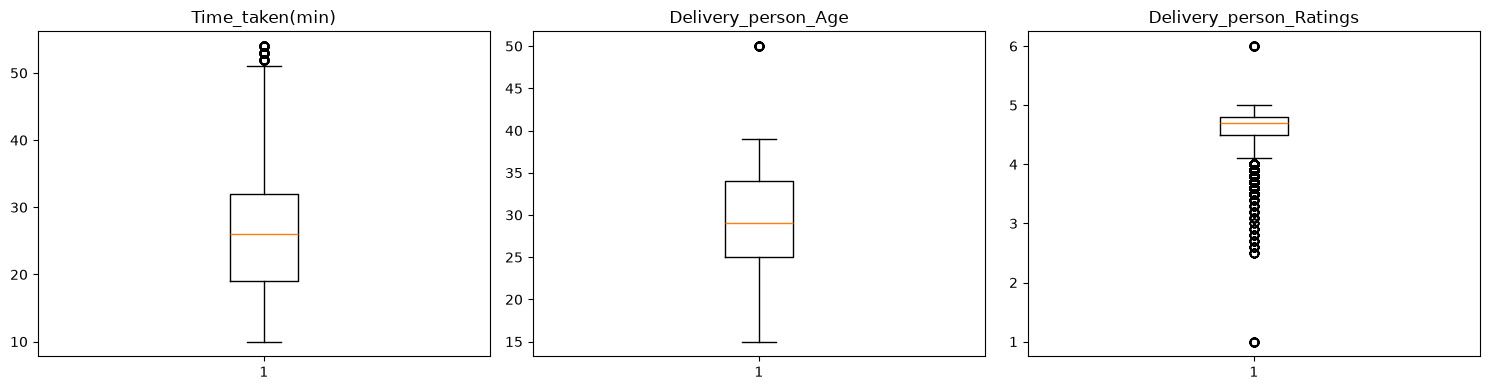

In [34]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(df['Time_taken(min)'])
axes[0].set_title('Time_taken(min)')

axes[1].boxplot(df['Delivery_person_Age'])
axes[1].set_title('Delivery_person_Age')

axes[2].boxplot(df['Delivery_person_Ratings'])
axes[2].set_title('Delivery_person_Ratings')

plt.tight_layout()
plt.show()

In [35]:
df[df['Delivery_person_Ratings'] > 5]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
3586,0x46d,BANGRES05DEL01,50,6.0,12.970324,77.645748,13.010324,77.685748,13-03-2022,NaN,12:30:00,NaN,Low,3,Meal,electric_scooter,0,No,Urban,25
4714,0x493,HYDRES17DEL01,50,6.0,17.451976,78.385883,17.561976,78.495883,04-04-2022,NaN,23:20:00,NaN,Low,3,Snack,bicycle,0,No,Metropolitian,27
5169,0x4f2,JAPRES08DEL01,50,6.0,26.910262,75.783013,27.020262,75.893013,18-03-2022,NaN,18:50:00,NaN,Low,3,Drinks,scooter,1,No,Metropolitian,20
5362,0x430,BANGRES19DEL01,50,6.0,12.914264,77.678400,13.024264,77.788400,06-04-2022,NaN,20:55:00,NaN,Low,3,Meal,electric_scooter,1,No,Metropolitian,18
5651,0xbef1,AGRRES13DEL02,50,6.0,27.159795,78.042990,27.209795,78.092990,13-02-2022,NaN,18:05:00,NaN,Low,3,Drinks,scooter,1,No,Metropolitian,20
6394,0x427,JAPRES06DEL02,50,6.0,26.911927,75.797282,27.041927,75.927282,02-04-2022,NaN,22:10:00,NaN,Low,3,Meal,electric_scooter,0,No,Urban,20
7031,0x3eb,MYSRES15DEL02,50,6.0,12.352058,76.606650,12.372058,76.626650,15-03-2022,NaN,10:00:00,NaN,Low,3,Buffet,scooter,1,No,Metropolitian,14
9499,0x3f0,BANGRES010DEL01,50,6.0,12.933298,77.614293,13.003298,77.684293,12-03-2022,NaN,18:25:00,NaN,Low,3,Drinks,scooter,1,No,Urban,17
9535,0x3ef,RANCHIRES13DEL01,50,6.0,23.374989,85.335486,23.444989,85.405486,20-03-2022,NaN,17:55:00,NaN,Low,3,Snack,bicycle,1,No,Metropolitian,32
10100,0x5b0,MYSRES04DEL01,50,6.0,12.308500,76.665808,12.418500,76.775808,18-03-2022,NaN,20:10:00,NaN,Low,3,Snack,electric_scooter,1,No,Metropolitian,35


In [36]:
df.loc[df['Delivery_person_Ratings'] > 5, 'Delivery_person_Ratings'] = np.nan


In [37]:
med = df['Delivery_person_Ratings'].median()
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(med)
print("Values > 5:", (df['Delivery_person_Ratings'] > 5).sum())
print("Missing:", df['Delivery_person_Ratings'].isnull().sum())

Values > 5: 0
Missing: 0


### Invalid Value — `Delivery_person_Ratings`

One row contained a rating of 6, which is outside the valid range for this
variable (0-5). This is a physically impossible value, likely a data entry
error (e.g. a typo), not a legitimate extreme rating.

**Decision:** the invalid value was treated as missing and replaced using
median imputation, consistent with our earlier handling of this column
(chosen for its robustness to the strong negative skew observed in ratings).

In [38]:
df[df['Delivery_person_Age'] < 15][['Delivery_person_Age']].describe()


,Delivery_person_Age
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [39]:
print(df['Delivery_person_Age'].max())
print("-" * 40)
df[df['Delivery_person_Age'] > 47.5]['Delivery_person_Age'].describe()

50
----------------------------------------


count    46.0
mean     50.0
std       0.0
min      50.0
25%      50.0
50%      50.0
75%      50.0
max      50.0
Name: Delivery_person_Age, dtype: float64

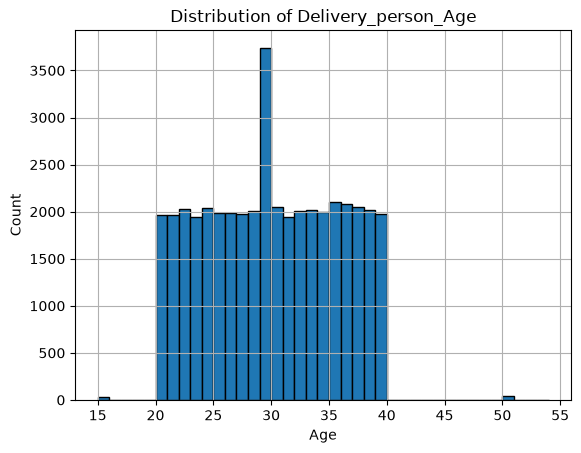

Delivery_person_Age
15      35
20    1964
21    1965
22    2029
23    1939
24    2044
25    1988
26    1988
27    1973
28    2004
29    3739
30    2050
31    1943
32    2010
33    2014
34    1995
35    2099
36    2083
37    2047
38    2020
39    1978
50      46
Name: count, dtype: int64


In [40]:
df['Delivery_person_Age'].hist(bins=range(15, 55, 1), edgecolor='black')
plt.title('Distribution of Delivery_person_Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

print(df['Delivery_person_Age'].value_counts().sort_index())

In [41]:
df.loc[df['Delivery_person_Age'] == 50, 'Delivery_person_Age'] = np.nan
mean_age = df['Delivery_person_Age'].mean()
print(mean_age)

29.5177893907939


In [42]:
df.loc[df['Delivery_person_Age'] == 15, 'Delivery_person_Age'] = np.nan

mean_age = df['Delivery_person_Age'].mean()
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(mean_age).astype(int)

print(df['Delivery_person_Age'].isnull().sum())
print(df['Delivery_person_Age'].value_counts().sort_index())

0
Delivery_person_Age
20    1964
21    1965
22    2029
23    1939
24    2044
25    1988
26    1988
27    1973
28    2004
29    3820
30    2050
31    1943
32    2010
33    2014
34    1995
35    2099
36    2083
37    2047
38    2020
39    1978
Name: count, dtype: int64


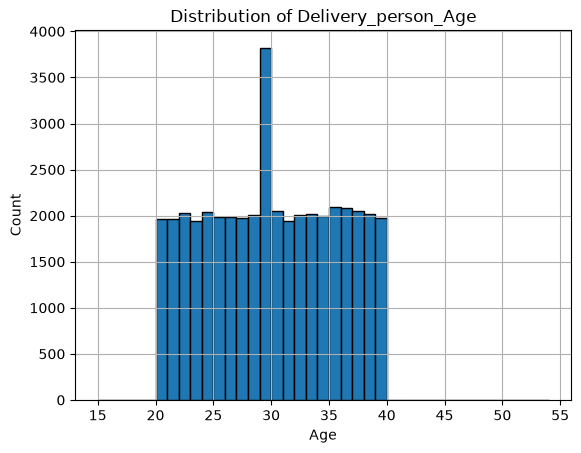

In [43]:
df['Delivery_person_Age'].hist(bins=range(15, 55, 1), edgecolor='black')
plt.title('Distribution of Delivery_person_Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [44]:
Q1 = df['Time_taken(min)'].quantile(0.25)
Q3 = df['Time_taken(min)'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Upper bound: {upper_bound:.2f}")

outliers = df[df['Time_taken(min)'] > upper_bound]
print(f"Number of outliers: {len(outliers)}")

outliers[['Time_taken(min)', 'Weatherconditions', 'Road_traffic_density', 
          'Festival', 'multiple_deliveries', 'Vehicle_condition']].sample(10, random_state=1)

Upper bound: 51.50
Number of outliers: 247


,Time_taken(min),Weatherconditions,Road_traffic_density,Festival,multiple_deliveries,Vehicle_condition
12663,52,Fog,Jam,No,1,0
45448,53,Windy,Jam,Yes,1,0
39385,52,Fog,Jam,No,1,0
40542,53,Cloudy,Jam,No,3,0
17370,53,Sandstorms,Jam,No,2,0
40035,53,Sandstorms,Jam,No,3,0
10971,54,Windy,Jam,No,1,0
24613,54,Sunny,Jam,No,0,0
34777,52,Sunny,Jam,No,1,0
722,53,Stormy,Jam,Yes,1,0


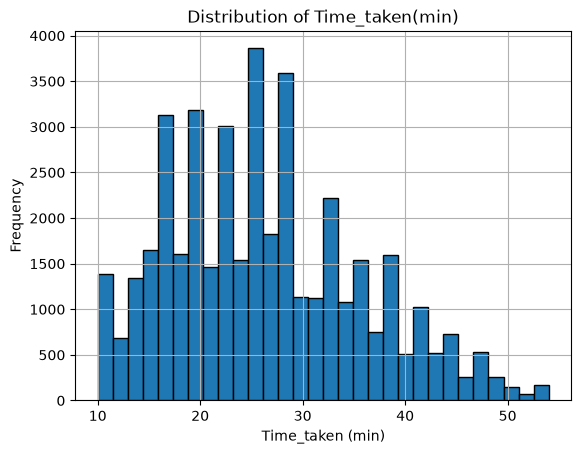

In [45]:
df['Time_taken(min)'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Time_taken(min)')
plt.xlabel('Time_taken (min)')
plt.ylabel('Frequency')
plt.show()

In [46]:
print(f"Mean: {df['Time_taken(min)'].mean():.2f}")
print(f"Median: {df['Time_taken(min)'].median():.2f}")
print(f"Skew: {df['Time_taken(min)'].skew():.2f}")

Mean: 26.31
Median: 26.00
Skew: 0.48


### Outlier Analysis — `Time_taken(min)`

IQR flagged 247 rows above 51.5 minutes as statistical outliers. Inspection of
a sample showed nearly all flagged rows had `Road_traffic_density = Jam`
(heaviest traffic level), often combined with adverse weather, festival days,
or multiple simultaneous deliveries.

**Decision:** outliers were kept. They represent legitimate delivery delays
explained by heavy traffic and compounding conditions, not data errors.
Removing them would bias the model against predicting realistic delivery
times under high-traffic conditions — exactly the scenario where accurate
ETAs matter most to the business.

In [47]:
import numpy as np

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

df['Distance_km'] = calculate_distance(
    df['Restaurant_latitude'], 
    df['Restaurant_longitude'], 
    df['Delivery_location_latitude'], 
    df['Delivery_location_longitude']
)

print(df[['Restaurant_latitude', 'Delivery_location_latitude', 'Distance_km']].head())

   Restaurant_latitude  Delivery_location_latitude  Distance_km
0            22.745049                   22.765049     3.025149
1            12.913041                   13.043041    20.183530
2            12.914264                   12.924264     1.552758
3            11.003669                   11.053669     7.790401
4            12.972793                   13.012793     6.210138


In [48]:
columns_to_drop = [
    'Restaurant_latitude', 
    'Restaurant_longitude', 
    'Delivery_location_latitude', 
    'Delivery_location_longitude',
    'ID',
    'Delivery_person_ID'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

print(df.columns)

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Date',
       'Time_Orderd', 'Time_Order_picked', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'Time_taken(min)', 'Distance_km'],
      dtype='str')


In [49]:
df[['Order_Date','Time_Orderd','Time_Order_picked','Time_taken(min)']].head()

,Order_Date,Time_Orderd,Time_Order_picked,Time_taken(min)
0,19-03-2022,11:30:00,11:45:00,24
1,25-03-2022,19:45:00,19:50:00,33
2,19-03-2022,08:30:00,08:45:00,26
3,05-04-2022,18:00:00,18:10:00,21
4,26-03-2022,13:30:00,13:45:00,30


In [50]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', errors='coerce')
df['Is_Weekend'] = df['Order_Date'].dt.dayofweek.isin([5, 6]).astype(int)
print(df[['Order_Date', 'Is_Weekend']].head(10))

  Order_Date  Is_Weekend
0 2022-03-19           1
1 2022-03-25           0
2 2022-03-19           1
3 2022-04-05           0
4 2022-03-26           1
5 2022-03-11           0
6 2022-03-04           0
7 2022-03-14           0
8 2022-03-20           1
9 2022-02-12           1


In [51]:
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S', errors='coerce')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce')

df['Prep_Time_min'] = (df['Time_Order_picked'] - df['Time_Orderd']).dt.total_seconds() / 60
print(df['Prep_Time_min'].describe())

count    40353.000000
mean       -17.213342
std        195.801775
min      -1435.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: Prep_Time_min, dtype: float64


In [52]:
print("Missing Prep_Time_min:", df['Prep_Time_min'].isnull().sum())
df[df['Prep_Time_min'] < 0][['Time_Orderd', 'Time_Order_picked', 'Prep_Time_min']].head(10)

Missing Prep_Time_min: 1600


,Time_Orderd,Time_Order_picked,Prep_Time_min
75,1900-01-01 23:50:00,1900-01-01 00:05:00,-1425.0
101,1900-01-01 23:55:00,1900-01-01 00:10:00,-1425.0
166,1900-01-01 23:45:00,1900-01-01 00:00:00,-1425.0
325,1900-01-01 23:55:00,1900-01-01 00:10:00,-1425.0
395,1900-01-01 23:55:00,1900-01-01 00:00:00,-1435.0
443,1900-01-01 23:45:00,1900-01-01 00:00:00,-1425.0
542,1900-01-01 23:45:00,1900-01-01 00:00:00,-1425.0
568,1900-01-01 23:55:00,1900-01-01 00:05:00,-1430.0
575,1900-01-01 23:50:00,1900-01-01 00:05:00,-1425.0
750,1900-01-01 23:45:00,1900-01-01 00:00:00,-1425.0


In [53]:
df.loc[df['Prep_Time_min'] < 0, 'Prep_Time_min'] += 1440

print(df['Prep_Time_min'].describe())

count    40353.000000
mean         9.978688
std          4.087331
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: Prep_Time_min, dtype: float64


In [54]:
missing_prep = df[df['Prep_Time_min'].isnull()]
print(missing_prep[['Time_Orderd', 'Time_Order_picked']].head(10))

    Time_Orderd   Time_Order_picked
42          NaT 1900-01-01 18:35:00
74          NaT 1900-01-01 15:30:00
120         NaT 1900-01-01 18:25:00
140         NaT 1900-01-01 23:40:00
179         NaT 1900-01-01 17:50:00
250         NaT 1900-01-01 21:25:00
289         NaT 1900-01-01 22:05:00
305         NaT 1900-01-01 19:45:00
348         NaT 1900-01-01 00:05:00
354         NaT 1900-01-01 23:05:00


In [55]:
print(f"Skew: {df['Prep_Time_min'].skew():.2f}")
print(f"Mean: {df['Prep_Time_min'].mean():.2f}")
print(f"Median: {df['Prep_Time_min'].median():.2f}")


Skew: 0.01
Mean: 9.98
Median: 10.00


In [56]:
mean_prep = df['Prep_Time_min'].mean()
df['Prep_Time_min'] = df['Prep_Time_min'].fillna(mean_prep)
print(df['Prep_Time_min'].isnull().sum()) 

0


In [57]:
missing_prep[['Time_Orderd', 'Time_Order_picked']].head(10)

,Time_Orderd,Time_Order_picked
42,NaT,1900-01-01 18:35:00
74,NaT,1900-01-01 15:30:00
120,NaT,1900-01-01 18:25:00
140,NaT,1900-01-01 23:40:00
179,NaT,1900-01-01 17:50:00
250,NaT,1900-01-01 21:25:00
289,NaT,1900-01-01 22:05:00
305,NaT,1900-01-01 19:45:00
348,NaT,1900-01-01 00:05:00
354,NaT,1900-01-01 23:05:00


In [58]:
df.head(10)

,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Is_Weekend,Prep_Time_min
0,37,4.9,2022-03-19,1900-01-01 11:30:00,1900-01-01 11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24,3.025149,1,15.0
1,34,4.5,2022-03-25,1900-01-01 19:45:00,1900-01-01 19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33,20.183530,0,5.0
2,23,4.4,2022-03-19,1900-01-01 08:30:00,1900-01-01 08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26,1.552758,1,15.0
3,38,4.7,2022-04-05,1900-01-01 18:00:00,1900-01-01 18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21,7.790401,0,10.0
4,32,4.6,2022-03-26,1900-01-01 13:30:00,1900-01-01 13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30,6.210138,1,15.0
5,22,4.8,2022-03-11,1900-01-01 21:20:00,1900-01-01 21:30:00,Cloudy,Jam,0,Buffet,motorcycle,1,No,Urban,26,4.610365,0,10.0
6,33,4.7,2022-03-04,1900-01-01 19:15:00,1900-01-01 19:30:00,Fog,Jam,1,Meal,scooter,1,No,Metropolitian,40,16.600361,0,15.0
7,35,4.6,2022-03-14,1900-01-01 17:25:00,1900-01-01 17:30:00,Cloudy,Medium,2,Meal,motorcycle,1,No,Metropolitian,32,20.205253,0,5.0
8,22,4.8,2022-03-20,1900-01-01 20:55:00,1900-01-01 21:05:00,Stormy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,34,19.975520,1,10.0
9,36,4.2,2022-02-12,1900-01-01 21:55:00,1900-01-01 22:10:00,Fog,Jam,2,Snack,motorcycle,3,No,Metropolitian,46,10.280582,1,15.0


In [59]:
mean_prep = df['Prep_Time_min'].mean()
df['Prep_Time_min'] = df['Prep_Time_min'].fillna(mean_prep)
print("Missing Prep_Time_min:", df['Prep_Time_min'].isnull().sum())

df = df.drop(columns=['Time_Orderd', 'Time_Order_picked'], errors='ignore')
print(df.columns.tolist())

print(df['Distance_km'].describe())
print("-" * 40)
print("Missing Order_Date:", df['Order_Date'].isnull().sum())


Missing Prep_Time_min: 0
['Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Date', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)', 'Distance_km', 'Is_Weekend', 'Prep_Time_min']
count    41953.000000
mean         9.720284
std          5.603083
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: Distance_km, dtype: float64
----------------------------------------
Missing Order_Date: 0


### Feature Engineering — Time Columns

**`Order_Date`**
Parsed from string to datetime (`%d-%m-%Y` format). Used to derive a new
feature, `Is_Weekend` (1 if the order was placed on Saturday/Sunday, else 0).
`Order_Date` itself was kept in the dataset (0 missing values after parsing).

**`Time_Orderd` and `Time_Order_picked`**
Parsed from string to datetime (`%H:%M:%S` format), then used to calculate a
new feature: `Prep_Time_min = Time_Order_picked − Time_Orderd`, representing
how long the restaurant took to prepare the order before pickup.

Two issues were found and fixed before this feature could be trusted:
- **Midnight rollover bug**: orders placed late at night (~23:4x-23:5x) and
  picked up just after midnight produced large negative durations
  (e.g. -1425 min), since both times were parsed onto the same reference date
  and the subtraction didn't account for the day boundary. Fixed by adding
  1440 minutes (24 hours) to any negative result.
- **1,600 missing values**: caused by unparseable `Time_Orderd` values in the
  raw data. Imputed using the mean, since the resulting `Prep_Time_min`
  distribution was symmetric (skew ≈ 0.01).

After extracting `Prep_Time_min`, the original `Time_Orderd` and
`Time_Order_picked` columns were dropped — their useful information is fully
captured in the new feature, and keeping the raw timestamps would be
redundant for modeling.

In [60]:
print(df.describe())
print("-" * 50)


       Delivery_person_Age  Delivery_person_Ratings  \
count         41953.000000             41953.000000   
mean             29.528901                 4.633802   
min              20.000000                 1.000000   
25%              25.000000                 4.500000   
50%              29.000000                 4.700000   
75%              34.000000                 4.800000   
max              39.000000                 5.000000   
std               5.637089                 0.325577   

                       Order_Date  Vehicle_condition  multiple_deliveries  \
count                       41953       41953.000000         41953.000000   
mean   2022-03-14 04:37:32.692298           1.022716             0.750745   
min           2022-02-11 00:00:00           0.000000             0.000000   
25%           2022-03-05 00:00:00           0.000000             0.000000   
50%           2022-03-15 00:00:00           1.000000             1.000000   
75%           2022-03-27 00:00:00         

In [61]:
categorical_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order', 
                     'Type_of_vehicle', 'Festival', 'City']

for col in categorical_cols:
    print(f"{col}:")
    print(df[col].value_counts())
    print("-" * 50)

Weatherconditions:
Weatherconditions
Fog           7012
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
NaN            569
Name: count, dtype: int64
--------------------------------------------------
Road_traffic_density:
Road_traffic_density
Low       14755
Jam       13043
Medium    10084
High       4071
Name: count, dtype: int64
--------------------------------------------------
Type_of_order:
Type_of_order
Snack      10616
Meal       10524
Drinks     10445
Buffet     10368
Name: count, dtype: int64
--------------------------------------------------
Type_of_vehicle:
Type_of_vehicle
motorcycle          24396
scooter             14029
electric_scooter     3468
bicycle                60
Name: count, dtype: int64
--------------------------------------------------
Festival:
Festival
No     41131
Yes      822
Name: count, dtype: int64
--------------------------------------------------
City:
City
Metropolitian    32525
Urban             9279
Se

In [62]:
print(df['City'].value_counts())
print("-" * 40)
print(df['Delivery_person_Ratings'].value_counts().sort_index().head(10))

City
Metropolitian    32525
Urban             9279
Semi-Urban         149
Name: count, dtype: int64
----------------------------------------
Delivery_person_Ratings
1.0    35
2.5    18
2.6    20
2.7    21
2.8    17
2.9    18
3.0     6
3.1    28
3.2    26
3.3    23
Name: count, dtype: int64


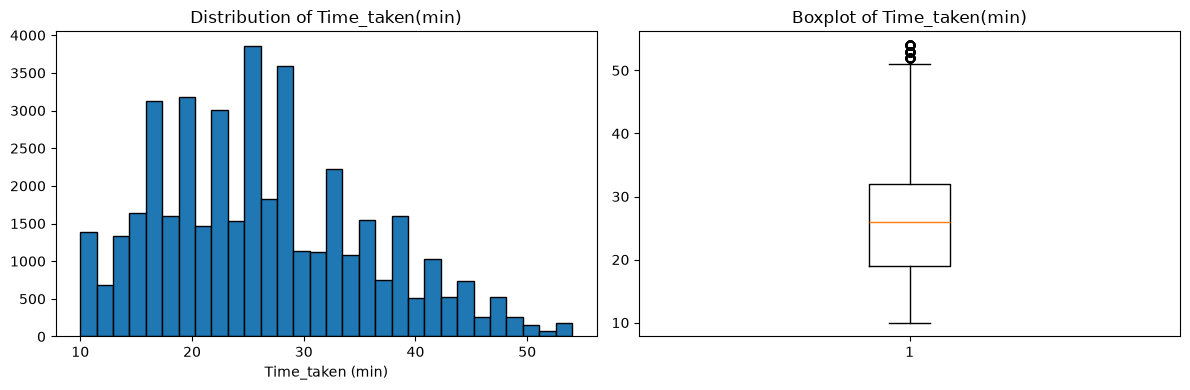

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Time_taken(min)'], bins=30, edgecolor='black')
axes[0].set_title('Distribution of Time_taken(min)')
axes[0].set_xlabel('Time_taken (min)')

axes[1].boxplot(df['Time_taken(min)'])
axes[1].set_title('Boxplot of Time_taken(min)')

plt.tight_layout()
plt.show()

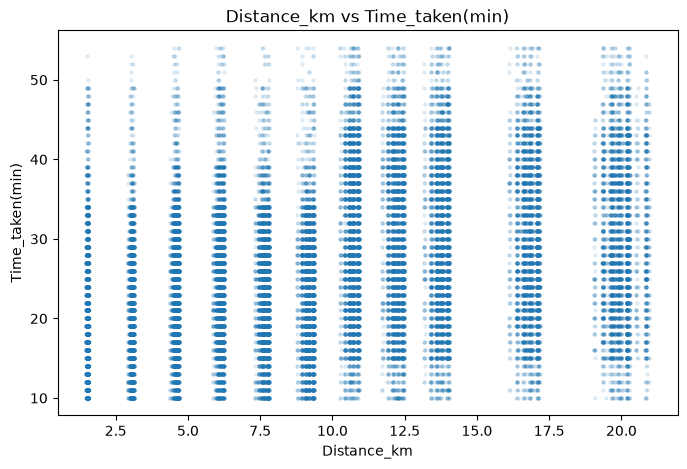

In [64]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Distance_km'], df['Time_taken(min)'], alpha=0.1, s=5)
plt.xlabel('Distance_km')
plt.ylabel('Time_taken(min)')
plt.title('Distance_km vs Time_taken(min)')
plt.show()

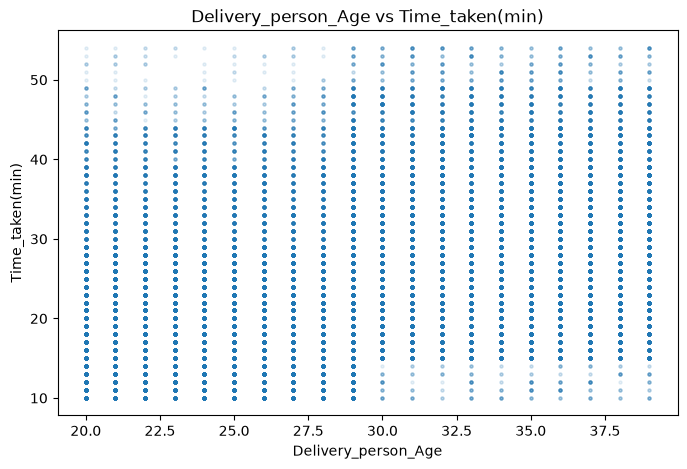

In [65]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Delivery_person_Age'], df['Time_taken(min)'], alpha=0.1, s=5)
plt.xlabel('Delivery_person_Age')
plt.ylabel('Time_taken(min)')
plt.title('Delivery_person_Age vs Time_taken(min)')
plt.show()

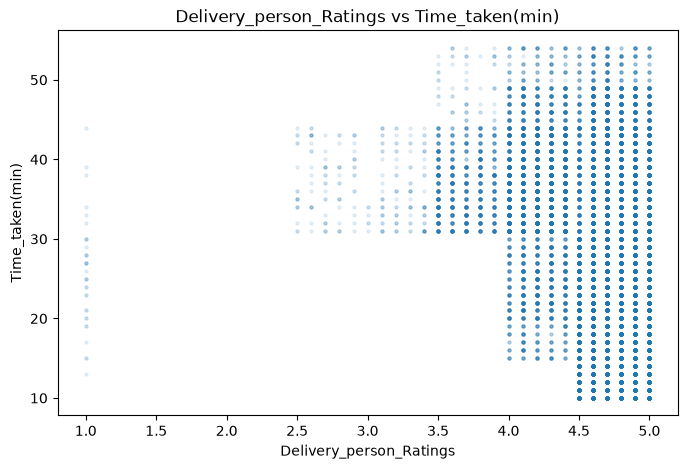

In [66]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Delivery_person_Ratings'], df['Time_taken(min)'], alpha=0.1, s=5)
plt.xlabel('Delivery_person_Ratings')
plt.ylabel('Time_taken(min)')
plt.title('Delivery_person_Ratings vs Time_taken(min)')
plt.show()

<Figure size 800x500 with 0 Axes>

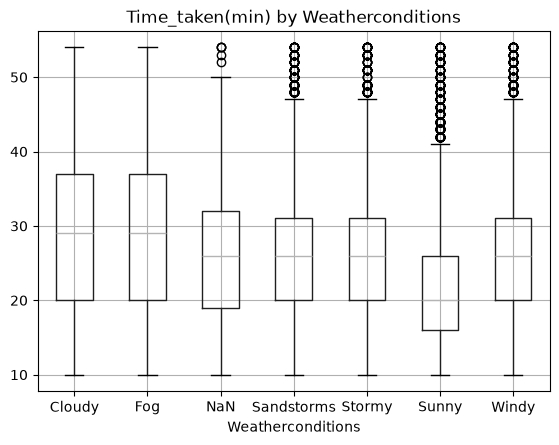

In [67]:
plt.figure(figsize=(8, 5))
df.boxplot(column='Time_taken(min)', by='Weatherconditions')
plt.title('Time_taken(min) by Weatherconditions')
plt.suptitle('')
plt.xlabel('Weatherconditions')
plt.show()

<Figure size 800x500 with 0 Axes>

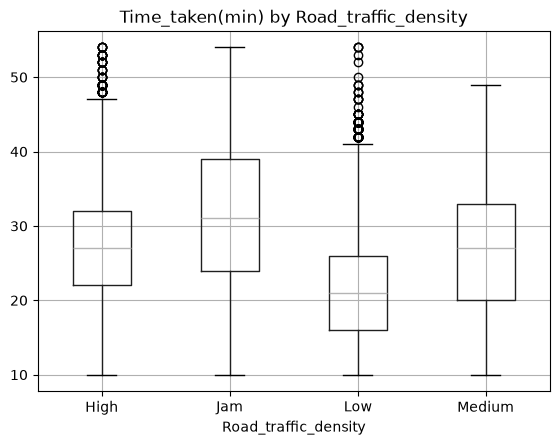

In [68]:
plt.figure(figsize=(8, 5))
df.boxplot(column='Time_taken(min)', by='Road_traffic_density')
plt.title('Time_taken(min) by Road_traffic_density')
plt.suptitle('')
plt.xlabel('Road_traffic_density')
plt.show()

<Figure size 800x500 with 0 Axes>

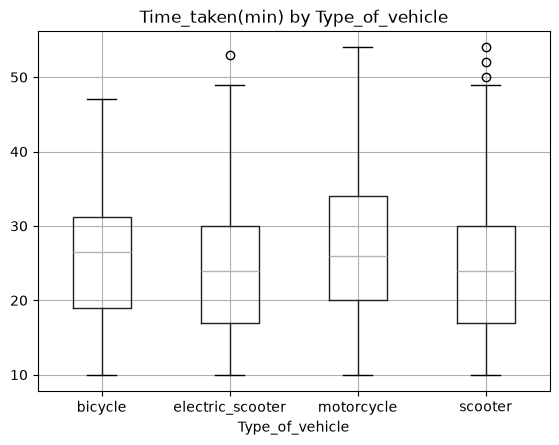

In [69]:
plt.figure(figsize=(8, 5))
df.boxplot(column='Time_taken(min)', by='Type_of_vehicle')
plt.title('Time_taken(min) by Type_of_vehicle')
plt.suptitle('')
plt.xlabel('Type_of_vehicle')
plt.show()

<Figure size 800x500 with 0 Axes>

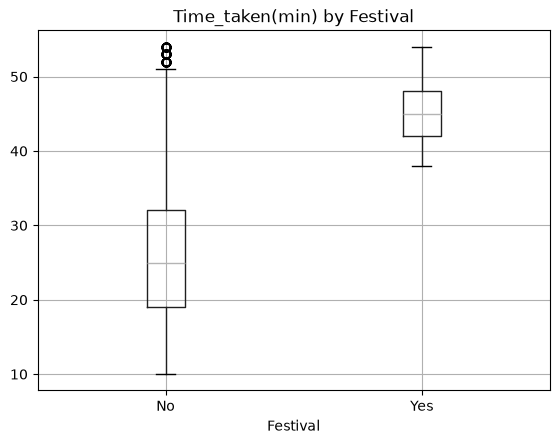

In [70]:
plt.figure(figsize=(8, 5))
df.boxplot(column='Time_taken(min)', by='Festival')
plt.title('Time_taken(min) by Festival')
plt.suptitle('')
plt.xlabel('Festival')
plt.show()

In [71]:
numerical_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition',
                   'multiple_deliveries', 'Distance_km', 'Is_Weekend', 'Prep_Time_min', 
                   'Time_taken(min)']

corr_matrix = df[numerical_cols].corr()
print(corr_matrix['Time_taken(min)'].sort_values(ascending=False))

Time_taken(min)            1.000000
multiple_deliveries        0.377921
Distance_km                0.320539
Delivery_person_Age        0.296214
Is_Weekend                -0.006435
Prep_Time_min             -0.009370
Vehicle_condition         -0.235016
Delivery_person_Ratings   -0.334508
Name: Time_taken(min), dtype: float64


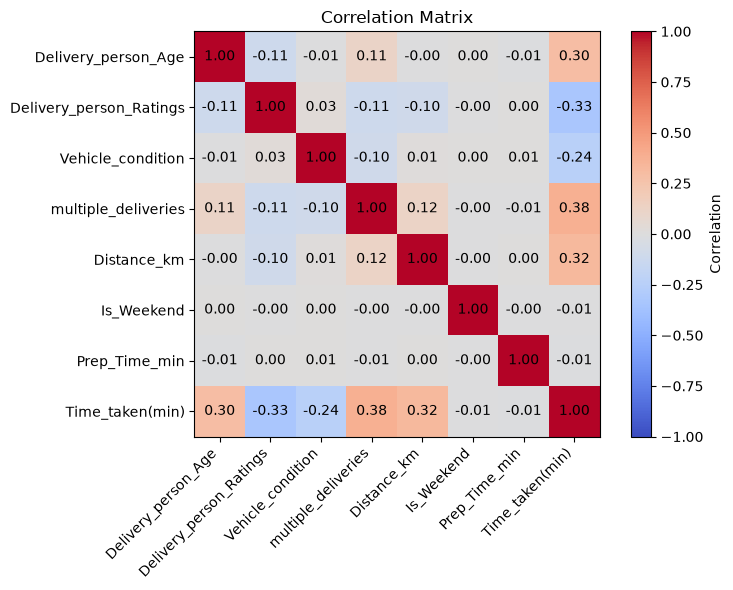

In [72]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [74]:
print(df['Vehicle_condition'].value_counts().sort_index())
print("-" * 40)

print(df.groupby('Vehicle_condition')['Time_taken(min)'].mean())

Vehicle_condition
0    13815
1    13851
2    13806
3      481
Name: count, dtype: int64
----------------------------------------
Vehicle_condition
0    30.091205
1    24.370659
2    24.479429
3    26.230769
Name: Time_taken(min), dtype: float64


In [75]:
df = df.drop(columns=['Vehicle_condition'])
print(df.columns.tolist())

['Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Date', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)', 'Distance_km', 'Is_Weekend', 'Prep_Time_min']


In [76]:
df.head(10)

,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Is_Weekend,Prep_Time_min
0,37,4.9,2022-03-19,Sunny,High,Snack,motorcycle,0,No,Urban,24,3.025149,1,15.0
1,34,4.5,2022-03-25,Stormy,Jam,Snack,scooter,1,No,Metropolitian,33,20.183530,0,5.0
2,23,4.4,2022-03-19,Sandstorms,Low,Drinks,motorcycle,1,No,Urban,26,1.552758,1,15.0
3,38,4.7,2022-04-05,Sunny,Medium,Buffet,motorcycle,1,No,Metropolitian,21,7.790401,0,10.0
4,32,4.6,2022-03-26,Cloudy,High,Snack,scooter,1,No,Metropolitian,30,6.210138,1,15.0
5,22,4.8,2022-03-11,Cloudy,Jam,Buffet,motorcycle,1,No,Urban,26,4.610365,0,10.0
6,33,4.7,2022-03-04,Fog,Jam,Meal,scooter,1,No,Metropolitian,40,16.600361,0,15.0
7,35,4.6,2022-03-14,Cloudy,Medium,Meal,motorcycle,1,No,Metropolitian,32,20.205253,0,5.0
8,22,4.8,2022-03-20,Stormy,Jam,Buffet,motorcycle,1,No,Metropolitian,34,19.975520,1,10.0
9,36,4.2,2022-02-12,Fog,Jam,Snack,motorcycle,3,No,Metropolitian,46,10.280582,1,15.0


In [79]:
from pathlib import Path
Project_Forlder = Path.cwd().parent
df.to_csv(Project_Folder / 'data' / 'processed' / 'cleaned_dataset.csv', index=False)